# 🌳 第 76 课 · MindSpore 计算图与静态图模式:从 PyNative 到整图下沉

> 动态图灵活好调试,静态图编译一次跑千遍 —— 用 torch.fx 亲手把 Python 变成一张静态图

**章节**: 第 11 章 · 华为昇腾与 MindSpore 生态

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解 PyNative(动态图)与 Graph(静态图)两种执行模式
- 掌握『整图下沉』:为什么静态图能绕开逐算子调度的开销
- 用 torch.fx 亲手演示『Python 函数 → 静态图』的捕获过程
- 认识 MindIR:MindSpore 的中间表示,跨端可移植
- 理解静态图执行 vs 动态图解释的性能差异,并跑通配套 App

## 📑 本课目录

1. **直觉:即兴演出 vs 拍电影** — 动态图像即兴,静态图像先拍完再上映
2. **两种模式对比** — PyNative 与 Graph 的执行方式、优劣与选择
3. **整图下沉** — 一次编译整图,整体下沉到昇腾执行
4. **亲手捕获静态图** — torch.fx symbolic_trace 把一个模型变成图
5. **MindIR:跨端中间表示** — MindSpore 的『通用图纸』MindIR
6. **性能账本与可视化** — 两种模式的耗时曲线(matplotlib)
7. **配套 Streamlit 演示** — app_76_mindspore_graph.py:动态 vs 静态对比

## 🔗 参考资料

- [MindSpore 官方文档](https://www.mindspore.cn)
- [MindSpore 动态图/静态图说明](https://www.mindspore.cn/docs/zh-CN/master/design/mindspore/mindspore.html)
- [PyTorch torch.fx 文档](https://pytorch.org/docs/stable/fx.html)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 OMP 库冲突(Windows)
import time, math
import numpy as np
import pandas as pd
import torch

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
print("本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。")

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。


## 1️⃣ 直觉:即兴演出 vs 拍电影 🎬

想象一台舞台剧:

- **即兴演出(动态图 / PyNative)**:演员想到哪演到哪,观众(程序员)随时喊"停,这段
  换个说法"。好处是灵活,坏处是**每次演出都要重新排练台词**(逐算子解释执行);
- **拍电影(静态图 / Graph)**:先把整部剧的脚本写好、排练、一次拍完,以后每场放映
  都只花放映时间。好处是**放映极快**,坏处是改台词(改模型)要**重新拍一遍**(重新编译)。

MindSpore 两种模式都支持,通过上下文切换:

```python
# 真实 MindSpore 代码(本机未安装,仅示意)
import mindspore as ms
ms.set_context(mode=ms.PYNATIVE_MODE)   # 动态图:灵活调试
ms.set_context(mode=ms.GRAPH_MODE)      # 静态图:编译整图、性能优先
```

选择逻辑很简单:**探索期用 PyNative,部署与长期运行用 Graph**。

## 2️⃣ 两种模式,一张对比表 ⚖️

| 维度 | PyNative(动态图) | Graph(静态图) |
|------|------------------|---------------|
| 执行方式 | 逐算子解释执行 | 先编译整图,再整体执行 |
| 灵活性 | 高:可随时 print / 改逻辑 | 低:改结构需重新编译 |
| 性能 | 每步有解释与调度开销 | 编译一次后,每轮开销极小 |
| 调试 | 像普通 Python 一样断点 | 要"看图"或打印图节点 |
| 内存 | 中间张量即时生成 | 编译期统一规划、可复用 |
| 典型场景 | 研究、调参、debug | 训练主力、部署、推理 |
| 昇腾契合 | 一般 | **可整图下沉,效率最高** |

关键句:**MindSpore 的 Graph 模式把计算图编译成可在昇腾上执行的任务,然后整图下沉
(整张图交给设备执行)**,省掉逐算子的 Host↔Device 往返 —— 这正是昇腾推理高性能的秘密。

## 3️⃣ 亲手捕获一张静态图:torch.fx 实战 🔬

MindSpore 的静态图在后台由编译器捕获;PyTorch 生态里同样的事由 **torch.fx** 完成。
我们把一个双层 MLP 交给 `symbolic_trace`,看它怎么变成"一张图" —— 这就是静态图
捕获的真实动作:

✅ 关键验证:eager 执行与『图执行』结果一致 —— 静态图是同一计算的不同执行方式,不是另一个模型。

In [2]:
import torch.fx as fx

class TinyMLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = torch.nn.Linear(8, 8)
        self.fc2 = torch.nn.Linear(8, 4)
    def forward(self, x):
        h = torch.relu(self.fc1(x))
        h = torch.relu(self.fc2(h))
        return torch.softmax(h, dim=-1)

net = TinyMLP()
gm = fx.symbolic_trace(net)      # 前端捕获:Python → 静态图
x = torch.randn(2, 8)
with torch.no_grad():
    y_eager = net(x)
    y_graph = gm(x)
print("eager 与 GraphModule 结果一致:", torch.allclose(y_eager, y_graph))
print("\n=== FX 计算图(静态图) ===")
print(gm.graph)

eager 与 GraphModule 结果一致: True

=== FX 计算图(静态图) ===
graph():
    %x : [num_users=1] = placeholder[target=x]
    %fc1 : [num_users=1] = call_module[target=fc1](args = (%x,), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%fc1,), kwargs = {})
    %fc2 : [num_users=1] = call_module[target=fc2](args = (%relu,), kwargs = {})
    %relu_1 : [num_users=1] = call_function[target=torch.relu](args = (%fc2,), kwargs = {})
    %softmax : [num_users=1] = call_function[target=torch.softmax](args = (%relu_1,), kwargs = {dim: -1})
    return softmax


🔍 静态图的妙处:图既是『可执行的结构』,又是『可读的代码』 —— MindSpore 的 MindIR 也是这样一张可序列化的图。

In [3]:
print("=== 从图再生成的 Python 代码(可读、可改、可再编译)===")
print(gm.code)

=== 从图再生成的 Python 代码(可读、可改、可再编译)===



def forward(self, x):
    fc1 = self.fc1(x);  x = None
    relu = torch.relu(fc1);  fc1 = None
    fc2 = self.fc2(relu);  relu = None
    relu_1 = torch.relu(fc2);  fc2 = None
    softmax = torch.softmax(relu_1, dim = -1);  relu_1 = None
    return softmax
    


## 4️⃣ 性能账本:编译一次,省下 N 次调度 📉

静态图到底快在哪?用第 73 课的思路再算一笔账:动态图每轮 = 每个算子都走一遍
"解释 + 启动";静态图 = 编译一次 + 每轮整图执行。画成累计耗时曲线,交叉点清晰可见:

📊 曲线:静态图开局被编译成本拖累,但每轮开销恒定且远小于动态图 —— 跑得越久,优势越大。这就是 LLM 训练与推理都倾向静态图的原因。

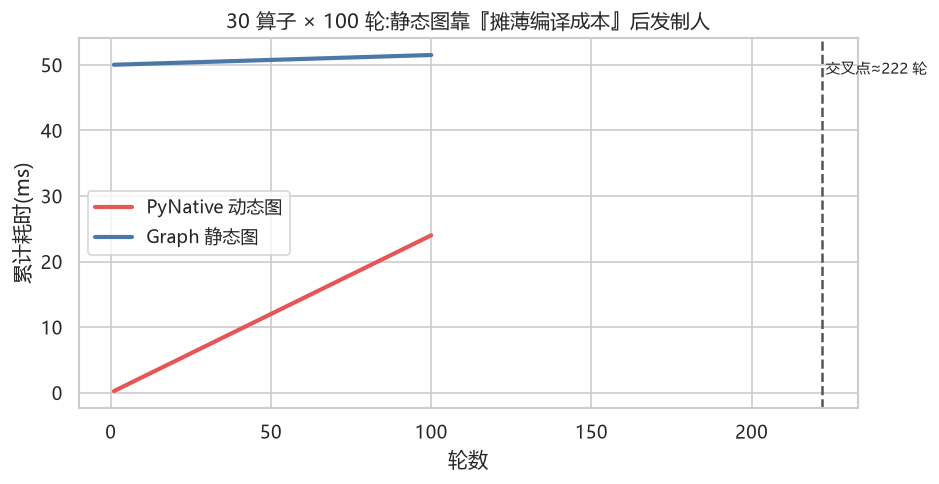

In [4]:
ops, iters = 30, 100
eager_us_per_op = 8.0        # 示意:动态图逐算子解释
static_us_per_iter = 15.0    # 示意:静态图每轮整体执行
compile_ms = 50.0            # 示意:静态图编译成本

rng = np.arange(1, iters + 1)
eager = eager_us_per_op * ops * rng / 1000
static = compile_ms + static_us_per_iter * rng / 1000
cross = int(compile_ms / ((eager_us_per_op * ops - static_us_per_iter) / 1000))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(rng, eager, label="PyNative 动态图", color="#E45756", lw=2.5)
ax.plot(rng, static, label="Graph 静态图", color="#4C78A8", lw=2.5)
ax.axvline(cross, ls="--", color="#555")
ax.text(cross + 1, ax.get_ylim()[1] * 0.9, f"交叉点≈{cross} 轮", fontsize=9)
ax.set_xlabel("轮数"); ax.set_ylabel("累计耗时(ms)")
ax.set_title(f"{ops} 算子 × {iters} 轮:静态图靠『摊薄编译成本』后发制人")
ax.legend(); plt.tight_layout()

## 5️⃣ MindIR:一张能到处跑的『图纸』 🗺️

MindSpore 图模式编译的产物是一种叫 **MindIR**(MindSpore IR)的中间表示:

- **跨硬件**:同一张 MindIR 可以下沉到昇腾、GPU、CPU,由后端各自编译;
- **可序列化**:MindIR 能存成文件,跨设备、跨进程传递 —— 训练好之后导出的就是它;
- **可移植**:下游的 MindSpore Lite、MindIE 都吃 MindIR —— 就像一张通用施工图,
  谁拿到都能照图施工。

类比 torch 生态:**MindIR ≈ torch.fx graph + ONNX 的可移植性**。我们在上一小节用
torch.fx 看到的 `gm.graph`,就是这一概念在 PyTorch 世界的对应物。

## 6️⃣ 配套 Streamlit 演示:动态 vs 静态对比 🎛️

运行同目录下的 `app_76_mindspore_graph.py`,可以**选择执行模式、拖动算子数与轮数**,
实时看两种模式的累计耗时曲线与交叉点:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_76_mindspore_graph.py
```

浏览器打开 **http://localhost:8501**。建议把算子数调大、轮数调小,观察交叉点右移
(编译成本占比变大);再把轮数拉到 500,静态图的优势一目了然。完整源码如下
(与同目录 `app_76_mindspore_graph.py` 一字不差):

📜 运行本 cell 会覆盖写入 `app_76_mindspore_graph.py`,保证 notebook 与 app 始终一致。

In [5]:
%%writefile app_76_mindspore_graph.py
# -*- coding: utf-8 -*-
# app_76_mindspore_graph.py — 动态图 vs 静态图对比 🌳
import streamlit as st
import plotly.graph_objects as go
import numpy as np

st.set_page_config(page_title="MindSpore 图模式 🌳", layout="wide")
st.title("🌳 第 76 课 · MindSpore 计算图:动态 vs 静态对比")

st.markdown("""
MindSpore 有两种执行模式: **PyNative(动态图)** —— 逐算子解释执行、灵活好调试;
**Graph(静态图)** —— 先编译整图、再整体下沉执行、性能高。二者是『灵活 vs 性能』的取舍。
下方**拖动算子数与迭代次数**,看两种模式的累积耗时如何变化;再观察编译一次的成本
怎么被摊薄。
""")

mode = st.sidebar.radio("执行模式", ["PyNative 动态图", "Graph 静态图"])
ops = st.sidebar.slider("图中算子个数", 5, 100, 30, 5)
iters = st.sidebar.slider("推理/训练轮数", 10, 500, 100, 10)
show_cost = st.sidebar.checkbox("显示编译成本明细", value=True)
st.sidebar.caption("动态图每轮都要逐算子解释;静态图只编译一次,之后整体执行。")

eager_per_iter = ops * 8.0        # 示意:动态图每轮耗时(μs/算子 → 累加)
static_per_iter = 15.0            # 示意:静态图每轮整体执行
compile_ms = 50.0                 # 示意:静态图一次编译成本(ms)

t_eager_total = eager_per_iter * iters / 1000     # ms
t_static_total = compile_ms + static_per_iter * iters / 1000

c1, c2, c3 = st.columns(3)
c1.metric("动态图总耗时", f"{t_eager_total:.1f} ms")
c2.metric("静态图总耗时", f"{t_static_total:.1f} ms")
c3.metric("静态图省时", f"{(t_eager_total - t_static_total) / max(t_eager_total, 1e-9) * 100:.0f}%")

rng = np.arange(1, iters + 1)
eager_curve = eager_per_iter * rng / 1000
static_curve = compile_ms + static_per_iter * rng / 1000

fig = go.Figure()
fig.add_trace(go.Scatter(x=rng, y=eager_curve, mode="lines",
                         line=dict(color="#E45756", width=3), name="PyNative 动态图"))
fig.add_trace(go.Scatter(x=rng, y=static_curve, mode="lines",
                         line=dict(color="#4C78A8", width=3), name="Graph 静态图"))
cross = int(compile_ms / ((eager_per_iter - static_per_iter) / 1000))
if cross > 0:
    fig.add_vline(x=min(cross, iters), line_dash="dash", line_color="#2F3B52",
                  annotation_text=f"交叉点 ≈ {cross} 轮", annotation_position="top right")
fig.update_layout(title=f"累计耗时:{ops} 个算子 × {iters} 轮(示意)",
                  xaxis_title="轮数", yaxis_title="累计耗时(ms)", height=400,
                  legend=dict(orientation="h", y=1.12))
st.plotly_chart(fig, use_container_width=True)
st.caption("⭐ 静态图早期被编译成本『拖累』,轮数越多反超越明显 —— 所以线上推理/长期训练偏爱静态图。")

if show_cost:
    st.subheader("📋 成本明细")
    st.markdown(f"""
| 项目 | 动态图 | 静态图 |
|---|---|---|
| 每轮耗时(示意) | {eager_per_iter/1000:.3f} ms(逐算子解释) | {static_per_iter/1000:.3f} ms(整体执行) |
| 编译成本 | 0 | {compile_ms} ms(一次性) |
| 调参/调试 | 灵活,可打印中间值 | 需重编译 |
""")

st.markdown("""
> 💡 **一句话**:MindSpore 的 PyNative 适合探索与调试,Graph 模式适合部署与长期运行。
> 企业落地 LLM 推理时几乎总是静态图 —— 这也是昇腾整图下沉的价值所在。
""")

Overwriting app_76_mindspore_graph.py


## ✅ 本课小结

- PyNative(动态图)逐算子解释、灵活好调试;Graph(静态图)编译整图、性能优先
- 整图下沉:静态图编译一次,整张图交给昇腾设备执行,省去逐算子 Host↔Device 往返
- torch.fx symbolic_trace 让我们亲眼看到『Python → 静态图』,且图执行与 eager 结果一致
- MindIR 是 MindSpore 的中间表示:跨硬件、可序列化、可移植,MindSpore Lite/MindIE 都吃它
- 性能账本:静态图摊薄编译成本,轮数越多优势越大 —— LLM 训练与推理偏爱静态图

## ✍️ 动手练习

1. 给 TinyMLP 加一个 dropout 层再 symbolic_trace,观察图节点如何变化(注意:fx 对 random 模块需换写法)
2. 把第 4 节曲线里 compile_ms 改成 200,重算交叉点,体会『编译成本高时该不该用静态图』
3. 用 fx.GraphModule 修改图(如把 relu 换成 gelu),重跑推理,验证『改图不改代码』
4. 查 MindSpore 文档,对比 MindIR 与 ONNX 的导出流程差异,各写 3 条要点

## 🔗 延伸阅读

- [MindSpore 官方文档](https://www.mindspore.cn)
- [MindSpore 静态图说明](https://www.mindspore.cn/docs/zh-CN/master/design/mindspore/mindspore.html)
- [PyTorch torch.fx 文档](https://pytorch.org/docs/stable/fx.html)

---
> 🎉 恭喜完成本课!下一课见!